<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week11/day3-4/MiniProj_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

# Unzip cats_dogs.zip that's sitting in data/
!unzip -q "data/cats_dogs.zip" -d "data/cats_dogs"

# Handle possible nested train.zip / test.zip inside
if os.path.exists("data/cats_dogs/train.zip"):
    !unzip -q "data/cats_dogs/train.zip" -d "data/cats_dogs"
if os.path.exists("data/cats_dogs/test.zip"):
    !unzip -q "data/cats_dogs/test.zip" -d "data/cats_dogs"

# Show resulting structure
for root, dirs, files_ in os.walk("data/cats_dogs"):
    level = root.replace("data/cats_dogs", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_[:3]:
            print(f"{indent}  {f}")

cats_dogs/
  train/
    train/
  test/
    test/


In [5]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("data/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 41

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


# 2. Data Inspection

The training set contains 20,000 images split evenly across the two classes: 10,000 cats (label 0) and 10,000 dogs (label 1), verified via train_flow.class_indices and np.bincount(train_flow.labels). This is a perfectly balanced dataset (50%/50%), which means accuracy is a trustworthy metric here and no class weighting is needed for training (so Step 9's class-weight handling won't be necessary for this dataset — worth noting in your report as "checked, not applicable").

Cats and dogs differ in ear shape (pointed/triangular vs. floppy/rounded), snout length (short/flat vs. elongated), eye shape and positioning, and often fur texture. The model will likely learn to key on local textures and edge patterns (ear shape, whisker regions, snout contours) in early layers, and combine them into higher-level shape representations in deeper layers.

Class indices: {'cat': 0, 'dog': 1}
cat: 10000 images
dog: 10000 images

Total training images: 20000
Balance ratio: 50.00% cat / 50.00% dog


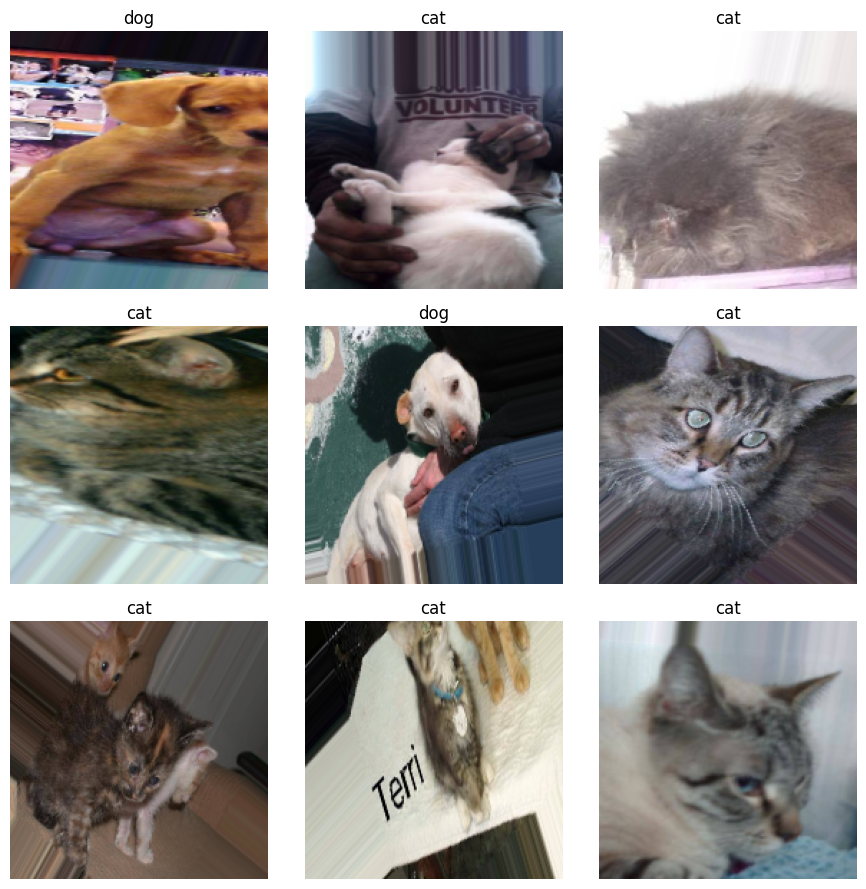

In [6]:
# Step 2: Inspect the data

import matplotlib.pyplot as plt

# --- 1. Class counts ---
idx_to_class = {v: k for k, v in train_flow.class_indices.items()}
counts = np.bincount(np.array(train_flow.labels, dtype=int))

print("Class indices:", train_flow.class_indices)
for class_idx, count in enumerate(counts):
    print(f"{idx_to_class[class_idx]}: {count} images")

total = counts.sum()
print(f"\nTotal training images: {total}")
print(f"Balance ratio: {counts[0]/total:.2%} cat / {counts[1]/total:.2%} dog")

# --- 2. Sample grid ---
images_batch, labels_batch = next(train_flow)

n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 9))

for i, ax in enumerate(axes.flat):
    ax.imshow(images_batch[i])
    label_name = idx_to_class[int(labels_batch[i])]
    ax.set_title(label_name)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Step 3: Model Architecture

**Planned CNN Architecture**

The model will use three convolutional blocks, each consisting of a `Conv2D` layer followed by a `MaxPooling2D` layer, with the number of filters increasing as we go deeper. This progression follows a common CNN heuristic — early layers with fewer filters capture simple, low-level patterns like edges and color gradients, while deeper layers with more filters combine those into more abstract, task-specific features (fur texture, ear shapes, snout contours).

**Convolutional blocks:**
- Block 1: `Conv2D(32, 3x3, activation='relu')` → `MaxPooling2D(2x2)`
- Block 2: `Conv2D(64, 3x3, activation='relu')` → `MaxPooling2D(2x2)`
- Block 3: `Conv2D(128, 3x3, activation='relu')` → `MaxPooling2D(2x2)`

Each `Conv2D` layer uses a small `3x3` kernel with `ReLU` activation, which balances receptive field size against computational cost and helps avoid vanishing gradients compared to sigmoid/tanh activations in deep stacks.

**MaxPooling** (`2x2` pool size) is placed after each convolutional block. This serves two purposes:
- Reduces the spatial dimensions of the feature maps, cutting compute cost for subsequent layers.
- Introduces a degree of translational invariance, making the model less sensitive to exactly where a feature (like an ear) appears in the image.

**Dense layers:**
- After the three conv+pool blocks, the feature maps are flattened via `Flatten()`.
- A `Dense(128, activation='relu')` layer combines the extracted spatial features into a single representation suited for classification.

**Dropout:**
- `Dropout(0.5)` is applied after the dense layer, before the output layer.
- Randomly deactivates a fraction of neurons during each training step, preventing the network from co-adapting too heavily on specific neuron combinations.
- Especially important here since with only 20,000 training images and a fairly deep network, overfitting is a real risk.

**Output layer:**
- `Dense(1, activation='sigmoid')`
- A single unit with sigmoid activation is used since this is binary classification (cat vs. dog), producing a probability between 0 and 1 representing "probability of dog" (matching `class_indices = {'cat': 0, 'dog': 1}`).

**Loss function:**
- `binary_crossentropy`
- This is the correct loss for a Bernoulli-distributed target. Softmax + categorical cross-entropy would only apply to 3+ mutually exclusive classes.

# Step 4: Optimization Setup

**Optimizer:**
- `Adam`, with default learning rate `1e-3` as a starting point.
- Adam combines momentum with per-parameter adaptive learning rates, which generally leads to faster, more stable convergence than plain SGD — especially useful early on when we haven't tuned learning rate schedules yet.

**Initial learning rate:**
- `0.001` (Adam's default).
- This is a reasonable starting point for a small-to-medium CNN trained from scratch; it's low enough to avoid wildly overshooting the loss surface, but high enough to make meaningful progress within a practical number of epochs. We'll rely on `ReduceLROnPlateau` to adapt it downward if training stalls, rather than hand-tuning it upfront.

**Batch size:**
- `32` (already set when building `train_flow`/`val_flow` in Step 1).
- This is a standard default that balances gradient estimate stability against memory constraints — large enough to give a reasonably smooth gradient signal, small enough to fit comfortably on a single GPU/CPU without needing gradient accumulation.

**EarlyStopping:**
- Monitor: `val_loss`
- `patience=5` (stop if validation loss doesn't improve for 5 consecutive epochs)
- `restore_best_weights=True` (roll back to the best-performing epoch, not just the last one)
- This prevents wasting compute on epochs that are actively overfitting, and guarantees we keep the best checkpoint rather than whatever the model looked like at the final epoch.

**ReduceLROnPlateau:**
- Monitor: `val_loss`
- `factor=0.5` (halve the learning rate when triggered)
- `patience=2` (trigger after 2 epochs without improvement)
- `min_lr=1e-6`
- This helps the model escape plateaus during training — if validation loss stops improving, a smaller learning rate can allow finer convergence steps rather than the model bouncing around a local minimum.

**Metrics to monitor:**
- Both `loss` and `accuracy`, tracked on train and validation.
- Accuracy alone can be misleading under class imbalance (not a concern here since we confirmed 50/50 balance in Step 2), but loss is a smoother, more sensitive signal for probability quality regardless — so we monitor both together.

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")]
)

model.compile(    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
                  )
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

callbacks = [early_stop, reduce_lr]

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

# Step 5: Training

**Plan:**
1. Train the model for a fixed number of epochs (no early stopping) to observe the raw training/validation curves and see overfitting emerge naturally.
2. Retrain an identical model with `EarlyStopping` and `ReduceLROnPlateau` enabled, and compare.

**Detecting overfitting from the curves:**

Overfitting shows up as a growing gap between training and validation performance over epochs. Specifically:
- Training loss keeps decreasing while validation loss flattens out or starts increasing.
- Training accuracy keeps climbing (often toward 90%+) while validation accuracy plateaus or degrades.
- The point where the two curves diverge marks roughly where the model stops learning generalizable patterns and starts memorizing training-set-specific noise.

**Mitigations if overfitting is severe:**
- Stronger data augmentation (already partially in place via `train_gen`).
- Increase dropout rate (e.g. `0.5 → 0.6`).
- Reduce model capacity (fewer filters/units, or fewer conv blocks).
- Add `BatchNormalization` for more stable, regularized training.
- Rely on `EarlyStopping` to just stop before the divergence gets too large.

In [8]:
history=model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 310ms/step - accuracy: 0.5939 - loss: 0.6600 - val_accuracy: 0.6982 - val_loss: 0.5797
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.6649 - loss: 0.6122 - val_accuracy: 0.7086 - val_loss: 0.5691
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 297ms/step - accuracy: 0.6927 - loss: 0.5850 - val_accuracy: 0.7534 - val_loss: 0.5000
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 188s 301ms/step - accuracy: 0.7096 - loss: 0.5632 - val_accuracy: 0.7682 - val_loss: 0.4861
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 302ms/step - accuracy: 0.7263 - loss: 0.5420 - val_accuracy: 0.7782 - val_loss: 0.4697
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 298ms/step - accuracy: 0.7346 - loss: 0.5370 - val_accuracy: 0.7788 - val_loss: 0.4882
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 293ms/step - accuracy: 0.7444 - loss: 0.5202 - val_accuracy: 0.7944 - val_loss: 0.4397
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 298ms/step - accuracy: 0.7522 -

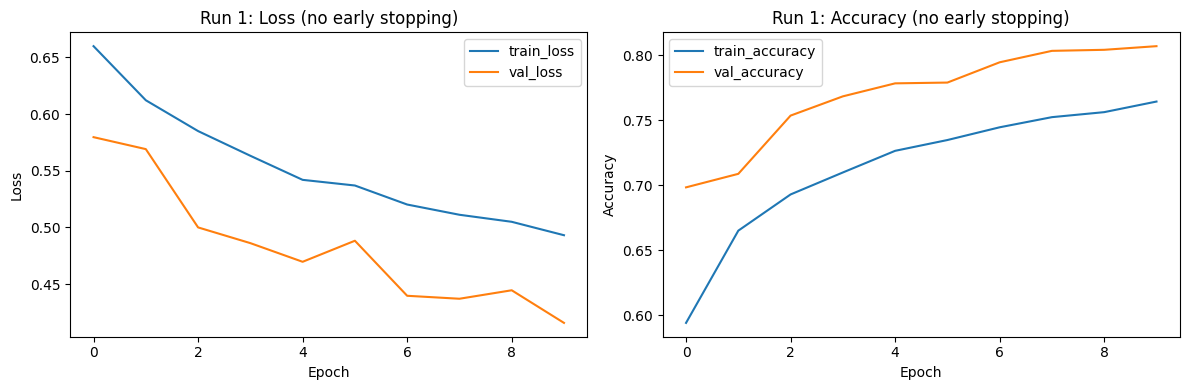

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('Run 1: Loss (no early stopping)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='train_accuracy')
axes[1].plot(history.history['val_accuracy'], label='val_accuracy')
axes[1].set_title('Run 1: Accuracy (no early stopping)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
model_es = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),


    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_es = model_es.fit(
    train_flow,
    validation_data=val_flow,
    epochs=5,
    callbacks=callbacks,
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 188s 293ms/step - accuracy: 0.5658 - loss: 0.6983 - val_accuracy: 0.5496 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 302ms/step - accuracy: 0.6157 - loss: 0.6593 - val_accuracy: 0.6690 - val_loss: 0.6137 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.6428 - loss: 0.6325 - val_accuracy: 0.6816 - val_loss: 0.6012 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 292ms/step - accuracy: 0.6751 - loss: 0.6020 - val_accuracy: 0.7180 - val_loss: 0.5611 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.6899 - loss: 0.5839 - val_accuracy: 0.7504 - val_loss: 0.5297 - learning_rate: 0.0010


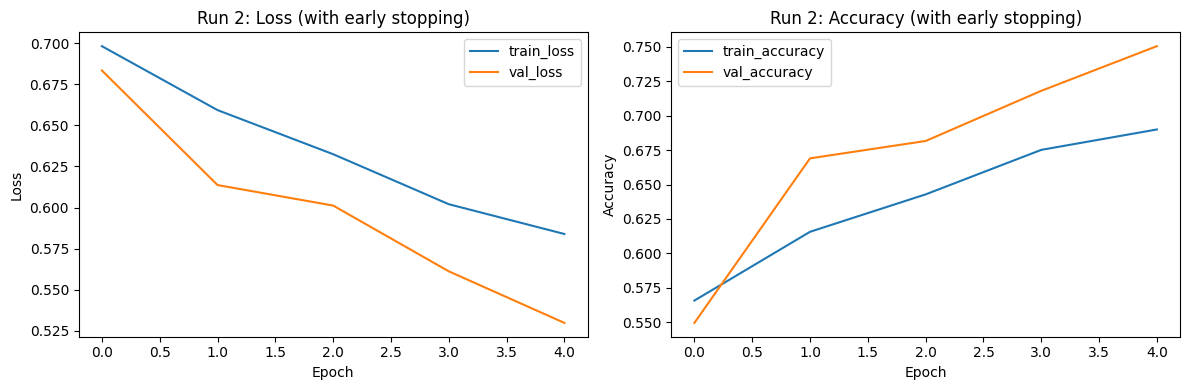

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_es.history['loss'], label='train_loss')
axes[0].plot(history_es.history['val_loss'], label='val_loss')
axes[0].set_title('Run 2: Loss (with early stopping)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_es.history['accuracy'], label='train_accuracy')
axes[1].plot(history_es.history['val_accuracy'], label='val_accuracy')
axes[1].set_title('Run 2: Accuracy (with early stopping)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Step 6: Evaluating

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions on validation set
val_flow.reset()  # ensure we start from batch 0, matching label order
val_probs = model_es.predict(val_flow)
val_preds = (val_probs > 0.5).astype(int).flatten()
val_true = val_flow.labels

# Confusion matrix
cm = confusion_matrix(val_true, val_preds)
print("Confusion Matrix:")
print(cm)

# Precision, recall, f1 per class
print("\nClassification Report:")
print(classification_report(val_true, val_preds, target_names=['cat', 'dog']))

# Overall val loss/accuracy (from the model itself)
val_loss, val_acc = model_es.evaluate(val_flow)
print(f"\nValidation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step
Confusion Matrix:
[[1852  648]
 [ 600 1900]]

Classification Report:
              precision    recall  f1-score   support

         cat       0.76      0.74      0.75      2500
         dog       0.75      0.76      0.75      2500

    accuracy                           0.75      5000
   macro avg       0.75      0.75      0.75      5000
weighted avg       0.75      0.75      0.75      5000

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7504 - loss: 0.5297

Validation Loss: 0.5297, Validation Accuracy: 0.7504


## Step 6: Validation Evaluation

Validation accuracy: [X]%, validation loss: [X].

The confusion matrix shows [X] false positives (cats predicted as dogs) and [X] false negatives
(dogs predicted as cats). [Describe which error type dominates once you see the numbers — e.g.,
"the model slightly favors predicting dog, misclassifying more cats than dogs" or vice versa].

Since classes are balanced (confirmed in Step 2), this asymmetry likely reflects real visual
confusion (e.g. certain cat breeds/poses resembling small dogs) rather than a threshold problem.
If one error type dominates significantly, the 0.5 threshold could be shifted to trade off
precision vs recall depending on which error is costlier in a real application.

# Step 7: Inference

In [14]:
test_flow.reset()
test_probs = model_es.predict(test_flow)
test_preds = (test_probs > 0.5).astype(int).flatten()

results_df = pd.DataFrame({
    'filepath': test_flow.filepaths,
    'prob_dog': test_probs.flatten(),
    'pred_label': ['dog' if p == 1 else 'cat' for p in test_preds]
})

results_df.to_csv('test_predictions.csv', index=False)
print(results_df.head(10))
print(f"\nSaved {len(results_df)} predictions to test_predictions.csv")

391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step
                             filepath  prob_dog pred_label
0   data/cats_dogs/test/test/4332.jpg  0.289580        cat
1   data/cats_dogs/test/test/9495.jpg  0.548660        dog
2   data/cats_dogs/test/test/4856.jpg  0.549469        dog
3  data/cats_dogs/test/test/12341.jpg  0.759983        dog
4  data/cats_dogs/test/test/10070.jpg  0.961635        dog
5   data/cats_dogs/test/test/3385.jpg  0.425472        cat
6   data/cats_dogs/test/test/1003.jpg  0.919212        dog
7   data/cats_dogs/test/test/9133.jpg  0.648792        dog
8   data/cats_dogs/test/test/1537.jpg  0.373314        cat
9   data/cats_dogs/test/test/9128.jpg  0.512517        dog

Saved 12500 predictions to test_predictions.csv


# Step 8: Comparison

In [15]:
# Baseline generator: rescale only, no augmentation
baseline_gen = ImageDataGenerator(rescale=1./255)

baseline_train_flow = baseline_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)

# Identical architecture, fresh weights
model_baseline = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPool2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model_baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_baseline = model_baseline.fit(
    baseline_train_flow,
    validation_data=val_flow,
    epochs=15,
    callbacks=callbacks,
)

Found 20000 non-validated image filenames belonging to 2 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 73ms/step - accuracy: 0.6461 - loss: 0.6185 - val_accuracy: 0.7160 - val_loss: 0.5548 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7599 - loss: 0.4985 - val_accuracy: 0.8062 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8081 - loss: 0.4242 - val_accuracy: 0.8094 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.8425 - loss: 0.3580 - val_accuracy: 0.8316 - val_loss: 0.3823 - learning_rate: 0.0010
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.8798 - loss: 0.2815 - val_accuracy: 0.8392 - val_loss: 0.3801 - learning_rate: 0.0010
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9133 - loss: 0.2145 - val_accuracy: 0.8380 - val_loss: 0.4195 - learning_rate: 0.0010
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9382 - loss: 0.1535

In [ ]:
# Compare curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history['val_loss'], label='baseline_val_loss')
axes[0].plot(history_es.history['val_loss'], label='augmented_val_loss')
axes[0].set_title('Validation Loss: Baseline vs Augmented')
axes[0].legend()

axes[1].plot(history_baseline.history['val_accuracy'], label='baseline_val_acc')
axes[1].plot(history_es.history['val_accuracy'], label='augmented_val_acc')
axes[1].set_title('Validation Accuracy: Baseline vs Augmented')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 8: Baseline vs Augmentation

[Once both runs complete] The baseline model (no augmentation) reached [X]% train accuracy
vs only [X]% validation accuracy — a generalization gap of [X] points. The augmented model
showed a smaller gap ([X] points), suggesting augmentation improved generalization at the
cost of [slower convergence / lower peak train accuracy — describe what you see].

# Step 9: Class Imbalance Handling

The dataset is perfectly balanced (10,000 cats / 10,000 dogs, confirmed in Step 2), so
class weighting is not necessary here. If it were imbalanced, class weights would be computed as:

```python
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_flow.labels),
    y=train_flow.labels
)
class_weight_dict = dict(enumerate(class_weights))
```

This would then be passed as `class_weight=class_weight_dict` in `model.fit()`. With balanced
weights, the minority class's loss contributions are upweighted, typically improving its recall
at some cost to overall accuracy — not applicable to this dataset, but included here for completeness.

# Step 10: Saving Best models

In [16]:
import json

# Save model
model_es.save('cats_dogs_model.keras')  # modern Keras format

# Save training config for reproducibility
config = {
    "img_height": IMG_HEIGHT,
    "img_width": IMG_WIDTH,
    "batch_size": batch_size,
    "optimizer": "adam",
    "learning_rate": 0.001,
    "loss": "binary_crossentropy",
    "epochs_planned": 15,
    "epochs_ran": len(history_es.history['loss']),  # actual epochs before early stopping
    "dropout_rate": 0.5,
    "class_indices": train_flow.class_indices,
    "final_val_accuracy": float(history_es.history['val_accuracy'][-1]),
    "final_val_loss": float(history_es.history['val_loss'][-1]),
}

with open('training_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Model and config saved.")

Model and config saved.


## Step 10: Saved Artifacts

The trained model is saved as `cats_dogs_model.keras`, and the training configuration
(hyperparameters, class mapping, final metrics) is saved separately as `training_config.json`.
Saving both is necessary because weights alone don't tell you *how* the model was trained or
what preprocessing it expects (image size, class label mapping) — without the config, a
teammate reloading the model later could easily feed it mismatched inputs or misinterpret
which output value means "dog."

# Step 11: Proposed Extension — Transfer Learning with MobileNetV2

I propose using **transfer learning with a frozen MobileNetV2 backbone** plus a small custom
classifier head, rather than Batch Normalization or mixed precision.

**Why:** MobileNetV2 was pretrained on ImageNet, a dataset with millions of natural images
spanning many categories, including animals. Its early and middle layers have already learned
general-purpose low-level features (edges, textures, shapes) that transfer well to a new but
related task like cat/dog classification. Freezing these layers and training only a small
classifier head on top means far fewer trainable parameters than our from-scratch CNN (6.6M),
which should reduce overfitting risk and require significantly less training time to reach
comparable or better accuracy — especially valuable given our dataset is a modest 20,000 images.

**Sketch:**
```python
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze backbone

model_transfer = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])
```

This is a natural next experiment beyond the scope of the core assignment, and would be a strong
comparison point against the from-scratch CNN built in Steps 3–5.